In [1]:
import numpy as np
import pandas as pd
import os

from pathlib import Path

def resolve_data_dir() -> Path:
    """Locate the dataset locally or on Kaggle."""
    candidates = [
        Path("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge"),
        Path("../data"),
        Path("data"),
        Path("."),
    ]
    for path in candidates:
        if (path / "train.csv").exists():
            return path
    raise FileNotFoundError(
        "Could not find train.csv. Place the CSVs in ../data (from notebooks/) "
        "or keep the default Kaggle input path."
    )

DATA_DIR = resolve_data_dir()
print("Using data directory:", DATA_DIR.resolve())


/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


# Importing Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_log_error, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

RANDOM_STATE = 42

# Loading Data

In [4]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_sub = pd.read_csv(DATA_DIR / "sample_submission.csv")

print('Train:', train.shape)
print('Test:', test.shape)


/tmp/ipykernel_23/124084528.py:1: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")


Train: (138701, 50)
Test: (15000, 49)


In [5]:
train.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


# Exploratory Data Analysis

In [6]:
print('Rows:', train.shape[0])
print('Columns:', train.shape[1])

Rows: 138701
Columns: 50


In [7]:
print('Target summary:')
print(train['TargetValue'].describe())

Target summary:
count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64


In [8]:
# checking missing values
missing = train.isnull().mean().sort_values(ascending=False) * 100
print(missing)

col19                        99.952416
col18                        99.952416
col5                         92.515555
col4                         92.515555
col27                        89.214930
col28                        89.214930
col29                        86.393753
col30                        86.393753
col13                        83.125572
col14                        83.125572
col7                         83.125572
col6                         83.125572
col9                         83.125572
col8                         83.125572
col11                        83.125572
col3                         78.909309
Forks                        78.861724
Spec_ReleaseSeries           76.282795
col1                         75.641127
col12                        72.340502
col15                        69.519326
DrivetrainType               64.856057
UtilizationTier              63.608770
Spec_VariantModifier         62.269919
col20                        48.799216
col25                    

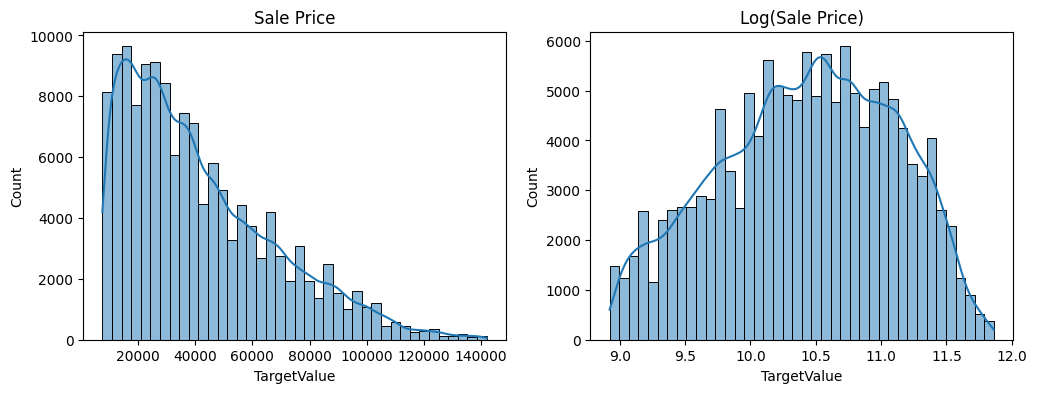

In [9]:
# distribution of target variables
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['TargetValue'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Sale Price')
sns.histplot(np.log1p(train['TargetValue']), bins=40, kde=True, ax=axes[1])
axes[1].set_title('Log(Sale Price)')
plt.show()

**Observation:**

Left Plot - raw sale price
1. The plot is right skewed and that means that the equipment sales for lower values with a long tail of expensive sales further
2. The distribution is not normal and it is clustered on the left with a few very high outliers

Right Plot - log(sale price)
1. After log transformation, the shape is much more symmetric and closer to the bell curve

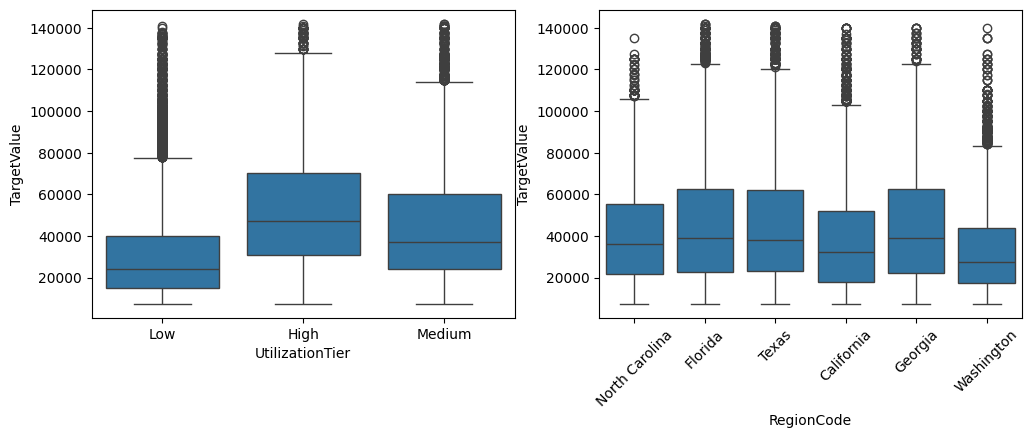

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=train, x='UtilizationTier', y='TargetValue', ax=axes[0])
top_regions = train['RegionCode'].value_counts().head(6).index
sns.boxplot(data=train[train['RegionCode'].isin(top_regions)], x='RegionCode', y='TargetValue', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
plt.show()

**Observation:**

Left Plot - Price by Utilization
1. Utilization tier strongly affects price so high utilization means higher sale price

Right plot - Price by Region
1. Medians are fairly similar across regions

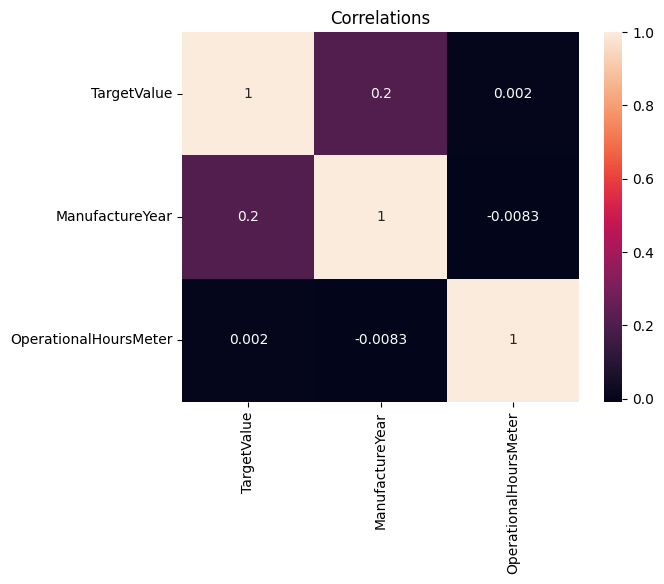

In [11]:
sns.heatmap(train[['TargetValue', 'ManufactureYear', 'OperationalHoursMeter']].corr(), annot=True)
plt.title('Correlations')
plt.show()

# Feature Engineering

In [12]:
NUM_COLS = ['ManufactureYear', 'OperationalHoursMeter', 'AssetAge', 'LogHours']
CAT_COLS = ['RegionCode', 'UtilizationTier', 'InventoryGroupCategory', 'CabinType']

In [13]:
def make_features(df):
    df = df.copy()
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
    df['AssetAge'] = df['TransactionDate'].dt.year - df['ManufactureYear']
    df['AssetAge'] = df['AssetAge'].clip(0, 50)
    hours = df['OperationalHoursMeter'].fillna(0)
    df['LogHours'] = np.log1p(hours)
    return df

In [14]:
train = make_features(train)
test = make_features(test)

X = train[NUM_COLS + CAT_COLS]
y = train['TargetValue']
X_test = test[NUM_COLS + CAT_COLS]

print('Number of features:', X.shape[1])
X.head()

Number of features: 8


,ManufactureYear,OperationalHoursMeter,AssetAge,LogHours,RegionCode,UtilizationTier,InventoryGroupCategory,CabinType
0,1997,4640.0,8,8.442685,North Carolina,Low,WL,EROPS w AC
1,2005,508.0,4,6.232448,Arizona,Low,BL,OROPS
2,1994,11540.0,11,9.353661,Florida,High,TEX,EROPS
3,2002,4883.0,4,8.493720,Illinois,High,BL,OROPS
4,2009,302.0,1,5.713733,Texas,Low,TEX,EROPS


# Preprocessing Pipeline

In [15]:
# fill missing values in numbers, then scale them
num_steps = Pipeline([
    ('fill', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# fill missing values in categries, then one-hot encode
cat_steps = Pipeline([
    ('fill', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_steps, NUM_COLS),
    ('cat', cat_steps, CAT_COLS)
])

# Evaluation

In [16]:
def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

score_fn = make_scorer(rmsle, greater_is_better=False)

# Model

In [17]:
# model 1
ridge = Pipeline([
    ('prep', preprocessor),
    ('model', Ridge())
])

ridge_search = GridSearchCV(ridge, {'model__alpha': [0.1, 1.0, 10.0]}, cv=3, scoring=score_fn)
ridge_search.fit(X, np.log1p(y))
ridge_pred = np.expm1(ridge_search.predict(X))
ridge_score = rmsle(y, ridge_pred)
print('Ridge RMSLE:', round(ridge_score, 4))

Ridge RMSLE: 0.5074


In [18]:
# model 2
rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_search = GridSearchCV(rf, {'model__n_estimators': [100, 200], 'model__max_depth': [10, 15]}, cv=3, scoring=score_fn)
rf_search.fit(X, np.log1p(y))
rf_pred = np.expm1(rf_search.predict(X))
rf_score = rmsle(y, rf_pred)
print('Random Forest RMSLE:', round(rf_score, 4))

Random Forest RMSLE: 0.4485


In [19]:
# model 3
gb = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

gb_search = GridSearchCV(gb, {'model__n_estimators': [100, 200], 'model__max_depth': [3, 5]}, cv=3, scoring=score_fn)
gb_search.fit(X, np.log1p(y))
gb_pred = np.expm1(gb_search.predict(X))
gb_score = rmsle(y, gb_pred)
print('Gradient Boosting RMSLE:', round(gb_score, 4))

Gradient Boosting RMSLE: 0.449


# Model Comparison

,Model,RMSLE
1,Random Forest,0.448471
2,Gradient Boosting,0.448985
0,Ridge,0.507358


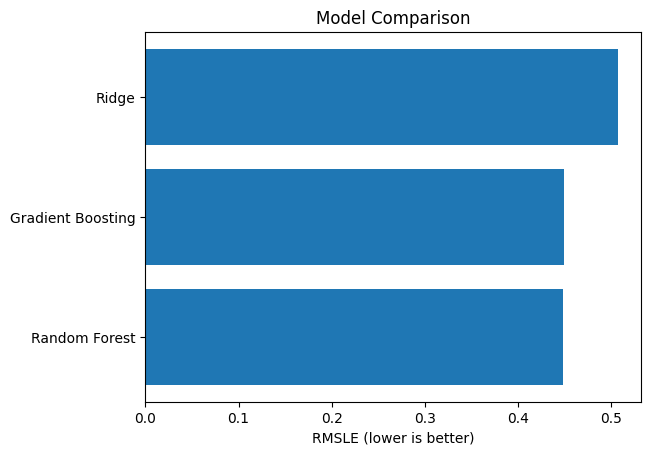

Best model: Random Forest


In [20]:
results = pd.DataFrame({
    'Model': ['Ridge', 'Random Forest', 'Gradient Boosting'],
    'RMSLE': [ridge_score, rf_score, gb_score]
}).sort_values('RMSLE')

display(results)

plt.barh(results['Model'], results['RMSLE'])
plt.xlabel('RMSLE (lower is better)')
plt.title('Model Comparison')
plt.show()

best = results.iloc[0]['Model']
print('Best model:', best)

# Training

In [21]:
if best == 'Ridge':
    final_model = ridge_search.best_estimator_
elif best == 'Random Forest':
    final_model = rf_search.best_estimator_
else:
    final_model = gb_search.best_estimator_

test_pred = np.expm1(final_model.predict(X_test))
test_pred = np.clip(test_pred, 0, None)

submission = pd.DataFrame({
    'TransactionID': sample_sub['TransactionID'],
    'TargetValue': test_pred
})
submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')
submission.head()

Saved submission.csv


,TransactionID,TargetValue
0,1139307,66482.672946
1,1139419,42670.428526
2,1139482,35694.493612
3,1139522,53915.320804
4,1139684,20827.803943


In [22]:
submission = pd.DataFrame({'TransactionID': sample_sub['TransactionID'],'TargetValue': test_predictions})

submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')
submission.head()

NameError: name 'test_predictions' is not defined

# Error Analysis

In [ ]:
if best == 'Ridge':
    preds = ridge_pred
elif best == 'Random Forest':
    preds = rf_pred
else:
    preds = gb_pred

errors = y - preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(preds, errors, alpha=0.3, s=5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set(xlabel='Predicted', ylabel='Error')
axes[1].scatter(y, preds, alpha=0.3, s=5)
mn, mx = min(y.min(), preds.min()), max(y.max(), preds.max())
axes[1].plot([mn, mx], [mn, mx], 'r--')
axes[1].set(xlabel='Actual', ylabel='Predicted')
plt.show()

print('Average error ($):', round(np.mean(np.abs(errors)), 2))

In [ ]:
import sys
sys.exit()

# Milestone 1

**Question 1 (MCQ):** Dataset Dimensions 

In [ ]:
print("Train dataset rows:", train.shape[0])
print("Test dataset rows:", test.shape[0])

**Question 2 (MCQ):** Target Variable Identification 

In [ ]:
set(train.columns) - set(test.columns)

**Question 3 (Numeric):** Feature Data Types

In [ ]:
print(train.select_dtypes(include='number').shape[1])

**Question 4 (MSQ):** Extremely Sparse Columns 

In [ ]:
missing_pct = train.isnull().mean() * 100

sparse_cols = missing_pct[missing_pct > 90]

print(f"Number of columns with >90% missing values: {len(sparse_cols)}")
print(sparse_cols.sort_values(ascending=False))

**Question 5 (Numeric):** Missing Operational Metrics 

In [ ]:
missing_count = train['OperationalHoursMeter'].isna().sum()
total_rows = len(train)

missing_pct = (missing_count / total_rows) * 100

print("Missing values:", missing_count)
print("Percentage missing:", round(missing_pct, 2), "%")

**Question 6 (MCQ):** Target Value Distribution 

In [ ]:
median_price = train['TargetValue'].median()
print(f"Median TargetValue: {median_price:,.0f}")

**Question 7 (Numeric):** Manufacture Year Anomaly

In [ ]:
train['ManufactureYear'].mode()

**Question 8 (MCQ):** Time Span of Transactions 

In [ ]:
train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])

print(train['TransactionDate'].min())

**Question 9 (Numeric):** High Cardinality Identification

In [ ]:
train['Spec_BaseClass'].nunique()

**Question 10 (MCQ):** Geographical Volume 

In [ ]:
train['RegionCode'].value_counts()

**Question 11 (Numeric):** Regional Pricing Insights 

In [ ]:
train[train['RegionCode'] == 'Florida']['TargetValue'].mean()

**Question 12 (MCQ):** Asset Utilization 

In [ ]:
train['UtilizationTier'].value_counts()

**Question 13 (MCQ):** Operational Correlation

In [ ]:
train[['TargetValue', 'OperationalHoursMeter']].corr(method='pearson')

**Question 14 (MCQ):** Primary Equipment Types

In [ ]:
train['FunctionalClassification'].mode()[0]

# Milestone 2

**Question 1**

In [ ]:
train["TransactionDate"] = pd.to_datetime(train["TransactionDate"])

In [ ]:
train["TransactionYear"] = train["TransactionDate"].dt.year
train["TransactionQuarter"] = train["TransactionDate"].dt.quarter

In [ ]:
train["AssetAge"] = train["TransactionYear"] - train["ManufactureYear"]

In [ ]:
train["DescriptorLength"] = (
    train["Spec_FullDescriptor"]
    .fillna("")
    .astype(str)
    .str.len()
)

In [ ]:
train["HasOperationalHours"] = train["OperationalHoursMeter"].notna().astype(int)
train["HasVariantModifier"] = train["Spec_VariantModifier"].notna().astype(int)

In [ ]:
most_frequent_asset_age = train["AssetAge"].mode()[0]
print("Most frequent AssetAge:", most_frequent_asset_age)

**Question 2**

In [ ]:
quarter_avg = train.groupby("TransactionQuarter")["TargetValue"].mean()
print("Average TargetValue by Quarter:")
print(quarter_avg.idxmax())

**Question 3**

In [ ]:
print("Maximum DescriptorLength:", train["DescriptorLength"].max())

**Question 4**

In [ ]:
count_operational = train["HasOperationalHours"].sum()
print("HasOperationalHours = 1:", count_operational)

**Question 5**

In [ ]:
variant_percent = train["HasVariantModifier"].mean() * 100
print("Percentage with Variant Info: {:.2f}%".format(variant_percent))

**Question 6**

In [ ]:
mean_year = train["ManufactureYear"].mean()
print("Mean ManufactureYear: {:.2f}".format(mean_year))

**Question 7**

In [ ]:
encoded = pd.get_dummies(
    train,
    columns=["RegionCode", "CabinType", "UtilizationTier"],
    drop_first=True
)

region_cols = pd.get_dummies(train["RegionCode"], drop_first=True).shape[1]
cabin_cols = pd.get_dummies(train["CabinType"], drop_first=True).shape[1]
util_cols = pd.get_dummies(train["UtilizationTier"], drop_first=True).shape[1]

total_encoded = region_cols + cabin_cols + util_cols

In [ ]:
print("Encoded Columns Created:", total_encoded)

**Question 8**

In [ ]:
numeric_cols = train.select_dtypes(include=np.number)
corr = numeric_cols.corr(method="pearson")
target_corr = corr["TargetValue"].abs().sort_values(ascending=False)

In [ ]:
print(target_corr)

**Question 9**

In [ ]:
features = ["ManufactureYear", "OperationalHoursMeter", "AssetAge"]

X = train[features].copy()
y = train["TargetValue"]

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
print("Training Shape:", X_train.shape)

**Question 10**

In [ ]:
print("Validation Shape:", X_valid.shape)

**Question 11**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X2 = train[["ManufactureYear", "AssetAge"]]

X2 = SimpleImputer(strategy="mean").fit_transform(X2)
X2 = StandardScaler().fit_transform(X2)

X_train2, X_valid2, y_train2, y_valid2 = train_test_split(
    X2,
    y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()
model.fit(X_train2, y_train2)

pred = model.predict(X_valid2)

r2 = r2_score(y_valid2, pred)

print("R2 Score:", r2)

# Milestone 3

**Question 1**

In [ ]:
train_df = train.copy()

In [ ]:
train_df["TransactionDate"] = pd.to_datetime(train_df["TransactionDate"])

train_df["SaleYear"] = train_df["TransactionDate"].dt.year

mode_sale_year = train_df["SaleYear"].mode()[0]

print(mode_sale_year)

**Question 2**

In [ ]:
train_df["ManufactureYear"] = train_df["ManufactureYear"].replace([1000, 1001], np.nan)

train_df["AssetAge"] = train_df["SaleYear"] - train_df["ManufactureYear"]

median_age = train_df["AssetAge"].median()

print(median_age)

**Question 3**

In [ ]:
missing_fraction = train_df.isna().mean()

cols_to_drop = missing_fraction[missing_fraction > 0.80]

print("Columns to drop:", len(cols_to_drop))
print(cols_to_drop.index.tolist())

**Question 4**

Median

**Question 5**

In [ ]:
filled = train_df["CabinType"].fillna("Missing")

missing_count = (filled == "Missing").sum()

print(missing_count)

**Question 6**

In [ ]:
train_df["HoursPerYear"] = (
    train_df["OperationalHoursMeter"] /
    train_df["AssetAge"]
)

train_df["HoursPerYear"] = train_df["HoursPerYear"].replace([np.inf, -np.inf], np.nan)

median_hours = train_df["HoursPerYear"].median()

print(median_hours)

**Question 7**

The categorical feature has very high cardinality

**Question 8**

In [ ]:
from sklearn.model_selection import train_test_split

df = train.copy()

X = df.drop(columns=["TargetValue"])
y = df["TargetValue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape[0])

**Question 9**

In [ ]:
import numpy as np

df = train.copy()

y_log = np.log1p(df["TargetValue"])

print(y_log.std())

**Question 10**

Before applying any scalers, target encoders, or median imputations.

**Question 11**

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

df = train.copy()

enc = OrdinalEncoder()

encoded = enc.fit_transform(df[["UtilizationTier"]])

print(len(enc.categories_[0]))

**Question 12**

Gradient Boosted Trees (LightGBM/XGBoost)

**Question 13**

The total number of individual decision trees built in the ensemble.

**Question 14**

The model used that specific feature frequently to make highly accurate splits in the decision trees, meaning it strongly influences the target prediction.

**Question 15**

It automatically halts training if the validation score stops improving, preventing the model from overfitting to the training data.

# Milestone 4

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

In [ ]:
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH  = DATA_DIR / "test.csv"

train_original = pd.read_csv(TRAIN_PATH)
test_original = pd.read_csv(TEST_PATH)


In [ ]:
train_df = train_original.copy(deep=True)
test_df = test_original.copy(deep=True)

**Question 1**

In [ ]:
train_df["UtilizationTier"] = train_df["UtilizationTier"].fillna("Unknown")

train_df["PriceBand"] = pd.qcut(
    train_df["TargetValue"],
    q=5,
    labels=False
)

X = train_df.drop(columns=["TargetValue"])
y = train_df["TargetValue"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=X["PriceBand"]
)

train_counts = (
    X_train["PriceBand"]
    .value_counts()
    .sort_index()
    .to_numpy()
)

valid_counts = (
    X_valid["PriceBand"]
    .value_counts()
    .sort_index()
    .to_numpy()
)

print("Train counts:", train_counts)
print("Validation counts:", valid_counts)


X_train_ns, X_valid_ns, y_train_ns, y_valid_ns = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=None
)

valid_counts_ns = (
    X_valid_ns["PriceBand"]
    .value_counts()
    .sort_index()
    .to_numpy()
)

print("Validation counts (non-stratified):")
print(valid_counts_ns)


prop_strat = valid_counts / valid_counts.sum()
prop_non = valid_counts_ns / valid_counts_ns.sum()

max_abs_diff = np.max(np.abs(prop_strat - prop_non))

print(round(max_abs_diff,4))

**Question 2**

In [ ]:
categorical_cols = [
    "UtilizationTier",
    "DrivetrainType",
    "CabinType",
    "AssetScaleFactor"
]

numeric_cols = [
    "ManufactureYear",
    "OperationalHoursMeter"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True
                ))
            ]),
            categorical_cols
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="mean")),
                ("scaler", StandardScaler())
            ]),
            numeric_cols
        )
    ],
    remainder="drop"
)

X_train_fit = X_train.drop(columns=["PriceBand"])
X_valid_fit = X_valid.drop(columns=["PriceBand"])

X_train_proc = preprocessor.fit_transform(X_train_fit)
X_valid_proc = preprocessor.transform(X_valid_fit)

print(round(X_train_proc.sum(),3))

**Question 3**

In [ ]:
rf = RandomForestRegressor(random_state=42)

param_dist = {
    "n_estimators":[50,100,200],
    "max_depth":[5,10,15]
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_proc, y_train)

print(search.best_params_["n_estimators"])

**Question 4**

In [ ]:
ada = AdaBoostRegressor(
    n_estimators=50,
    random_state=42
)

ada.fit(X_train_proc, y_train)

variance = np.var(ada.estimator_errors_)

print(round(variance,4))

**Question 5**

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train_proc, y_train)

importance = rf.feature_importances_

answer = np.argmax(importance)

print(answer)

**Question 6**

In [ ]:
N = X_train_proc.shape[1]

weights = (
    N*128 +
    128*64 +
    64*32 +
    32*1
)

print("Number of features:", N)
print(weights)

**Question 7**

In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128,64,32),
    activation="relu",
    solver="adam",
    batch_size=32,
    max_iter=5,
    random_state=42
)

mlp.fit(X_train_proc, y_train)

print(round(mlp.loss_,4))

**Question 8**

In [ ]:
modelA = MLPRegressor(
    hidden_layer_sizes=(100,),
    alpha=0.0001,
    max_iter=5,
    random_state=42
)

modelB = MLPRegressor(
    hidden_layer_sizes=(100,),
    alpha=1.0,
    max_iter=5,
    random_state=42
)

modelA.fit(X_train_proc, y_train)
modelB.fit(X_train_proc, y_train)

predA = modelA.predict(X_train_proc)
predB = modelB.predict(X_train_proc)

maeA = mean_absolute_error(y_train, predA)
maeB = mean_absolute_error(y_train, predB)

answer = abs(maeA - maeB)

print(round(answer,4))

**Question 9**

In [ ]:
valid_pred = mlp.predict(X_valid_proc)

mae_valid = mean_absolute_error(
    y_valid,
    valid_pred
)

print(round(mae_valid,4))